In [2]:
import numpy as np

import sklearn
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras

import seaborn as sns

import matplotlib.pyplot as plt

*a. generate data points in python using:*

In [3]:
#creating a data points
x_data = np.linspace(-0.5,0.5,200)[:,np.newaxis] 
noise = np.random.normal(0, 0.02, x_data.shape) 
y_data = np.square(x_data) + noise
print('x_data',len(x_data),', noise',len(noise),', y_data',len(y_data))
print("---------------------------Data points summary ---------------------------------------------------")
print("--------------------------------------------------------------------------------------------------")
print("First 2 feature value of input vactor X data value\n", x_data[0] , '\n', x_data[1])
print("--------------------------------------------------------------------------------------------------")
print("First 2 feature value of noise data\n",noise[0],'\n', noise[1])
print("--------------------------------------------------------------------------------------------------")
print("First 2 feature value of target vactor Y data value\n",y_data[0],'\n', y_data[1])


x_data 200 , noise 200 , y_data 200
---------------------------Data points summary ---------------------------------------------------
--------------------------------------------------------------------------------------------------
First 2 feature value of input vactor X data value
 [-0.5] 
 [-0.49497487]
--------------------------------------------------------------------------------------------------
First 2 feature value of noise data
 [0.0021959] 
 [0.00580018]
--------------------------------------------------------------------------------------------------
First 2 feature value of target vactor Y data value
 [0.2521959] 
 [0.2508003]


*b. Establish a linear regression model to predict y data (you can use sklearn)*

In [4]:
#Create linear regression model
regression = linear_model.LinearRegression()
#train the model 
regression.fit(x_data, y_data)
#prediction Making
y_pred = regression.predict(x_data)
#print("linear regression y Predicition\n", y_pred)
print("------------------------------ Summary of Linear Regression Analysis------------------------------")
print("First feature value of input vactor ", x_data[0])
print("First feature value of target vactor ",y_data[0])
print("First feature value of predict target vactor ",y_pred[0])
print("--------------------------------------------------------------------------------------------------")
print("The Coefficients", regression.coef_)
print("The Intercept", regression.intercept_)
print("--------------------------------------------------------------------------------------------------")


------------------------------ Summary of Linear Regression Analysis------------------------------
First feature value of input vactor  [-0.5]
First feature value of target vactor  [0.2521959]
First feature value of predict target vactor  [0.08554912]
--------------------------------------------------------------------------------------------------
The Coefficients [[-5.11578536e-05]]
The Intercept [0.08552354]
--------------------------------------------------------------------------------------------------


 *c. Establish a polynomial model with the highest power of 2 to predict y data (you can use Sklearn).*


In [5]:
#polynomial regression 
poly = PolynomialFeatures(degree=2)
x_polyData = poly.fit_transform(x_data)
#Create Linear Regression model
poly_reg = linear_model.LinearRegression()
#Train the model
poly_reg.fit(x_polyData, y_data) #Ground truth Ydata
# polynomial Regression y pridection 
y_predPoly= poly_reg.predict(x_polyData)
print("------------------------------ Summary of polynomial Regression Analysis------------------------------")
print("First feature value of input vactor", x_data[0])
print("First feature value of input polynomial vector", x_polyData[0])
print("First feature value of target vactor",y_data[0])
print("First feature value of predict target vactor", y_predPoly[0])
print("--------------------------------------------------------------------------------------------------")
print("polynomial regression coefficient", poly_reg.coef_ )
print("polynomial regression intercept", poly_reg.intercept_)
print("--------------------------------------------------------------------------------------------------")

------------------------------ Summary of polynomial Regression Analysis------------------------------
First feature value of input vactor [-0.5]
First feature value of input polynomial vector [ 1.   -0.5   0.25]
First feature value of target vactor [0.2521959]
First feature value of predict target vactor [0.2539954]
--------------------------------------------------------------------------------------------------
polynomial regression coefficient [[ 0.00000000e+00 -5.11578536e-05  1.01578211e+00]]
polynomial regression intercept [2.42894081e-05]
--------------------------------------------------------------------------------------------------


*d. Establish a three-layer (including input, 1 hidden (6 nodes), and output layer) neural network to predict y data (Keras or TensorFlow is recommended).Split the dataset into training 80% and testing data 20%.*

In [6]:
# creating neural network 
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size = 0.2, random_state = 0)
x_train, x_test = x_train / 255.0, x_test / 255.0

x_trainFt = tf.convert_to_tensor(x_train, name=None, dtype_hint=None, dtype=None)
y_trainFt =tf.convert_to_tensor(y_train, name=None, dtype_hint=None, dtype=None)
x_testFt=tf.convert_to_tensor(x_test, name=None, dtype_hint=None, dtype=None)
y_testFt =tf.convert_to_tensor(y_test, name=None, dtype_hint=None, dtype=None)

model = tf.keras.models.Sequential()
#1 input layer and 1 hidden layer with 6 nodes 
model.add(tf.keras.layers.Dense(6, input_dim=x_trainFt.shape[1], activation="relu"))
#output Layer
model.add(tf.keras.layers.Dense(1, activation='linear'))
model.compile(optimizer='adam', loss='mean_squared_error')
m_hist = model.fit(x_trainFt, y_trainFt, batch_size = 10,  epochs=100, verbose=1, validation_data=(x_testFt, y_testFt))

Epoch 1/100
16/16 [==============================] - 1s 27ms/step - loss: 0.0108 - val_loss: 0.0086
Epoch 2/100
16/16 [==============================] - 0s 6ms/step - loss: 0.0074 - val_loss: 0.0062
Epoch 3/100
16/16 [==============================] - 0s 5ms/step - loss: 0.0064 - val_loss: 0.0058
Epoch 4/100
16/16 [==============================] - 0s 6ms/step - loss: 0.0064 - val_loss: 0.0058
Epoch 5/100
16/16 [==============================] - 0s 8ms/step - loss: 0.0064 - val_loss: 0.0058
Epoch 6/100
16/16 [==============================] - 0s 5ms/step - loss: 0.0064 - val_loss: 0.0058
Epoch 7/100
16/16 [==============================] - 0s 6ms/step - loss: 0.0064 - val_loss: 0.0058
Epoch 8/100
16/16 [==============================] - 0s 7ms/step - loss: 0.0064 - val_loss: 0.0058
Epoch 9/100
16/16 [==============================] - 0s 9ms/step - loss: 0.0064 - val_loss: 0.0058
Epoch 10/100
16/16 [==============================] - 0s 4ms/step - loss: 0.0064 - val_loss: 0.0058
Epoch 11

*e. Calculate and compare mean squared errors of three models in (b), (c), and (d).*


In [10]:
#linear regression mean squared error 
lg_mse = format(mean_squared_error(y_data, y_pred),'.4f')
print("linear regression MSE:",lg_mse)
print("--------------------------------------------------------------------------------------------------\n")
#Polynomial regression mean squared error
poly_mse= format(mean_squared_error(y_data, y_predPoly),'.4f')
print("Polynomial regression MSE:",poly_mse)
print("--------------------------------------------------------------------------------------------------\n")
#Neural Network mean squared error
test_loss = model.evaluate(x_testFt, y_testFt, verbose=0)
print("Neural Network MSE: ", format(test_loss,'.4f'))

linear regression MSE: 0.0062
--------------------------------------------------------------------------------------------------

Polynomial regression MSE: 0.0004
--------------------------------------------------------------------------------------------------

Neural Network MSE:  0.0058


*f. Plot data points and curve of predictions in (b) and (c).*


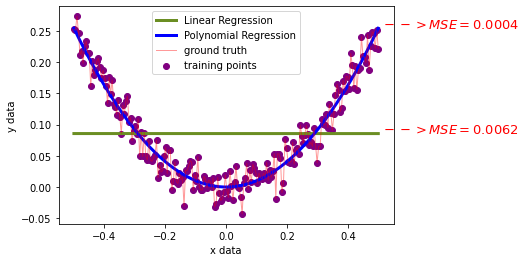

In [8]:
plt.scatter(x_data, y_data, color = 'purple', label='training points')
#linear regression plot 
plt.plot(x_data, y_pred, color='olivedrab', label='Linear Regression', linewidth=3)
plt.text(np.max(x_data), np.mean(y_pred), r'$\>-->MSE=  $'+lg_mse, fontsize=13, color="r")
#Polynomial regression plot 
plt.plot(x_data, y_predPoly,color='blue', label='Polynomial Regression', linewidth=3)
plt.text(np.max(x_data), np.max(y_predPoly), r'$\>-->MSE=  $'+poly_mse, fontsize=13, color="r")
# ground truth
plt.plot(x_data, y_data, color="red",alpha=0.4, linewidth=1, label="ground truth")

plt.legend(loc="upper center")
plt.xlabel('x data')
plt.ylabel('y data')
plt.show()